# Delivery SLA Reliability & Financial Exposure Analysis

**Notebook:** `01_data_quality_audit.ipynb`  
**Objective:** establish the correct data grain, build a valid order-level table, validate delivery KPIs, identify the strongest observed differentiators, measure financial exposure, and prepare the dataset for Tableau.

> **Interpretation boundary:** this analysis separates **association** from **causation**. Shipping mode can be described as the strongest observed differentiator in the data, but not as an operational root cause because the dataset does not include carrier, warehouse capacity, staffing, queue, or dispatch-operation data.

In [45]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Google Drive is now mounted at `/content/drive`, so the notebook can read project files and save outputs directly to Drive instead of relying on temporary Colab storage.

## 0.1 — Create the project folder structure

In [46]:
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/DEPP Delivery Project")

folders = [
    PROJECT_PATH / "data" / "raw",
    PROJECT_PATH / "data" / "processed",
    PROJECT_PATH / "notebooks",
    PROJECT_PATH / "outputs",
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project folder created at:\n{PROJECT_PATH}")

Project folder created at:
/content/drive/MyDrive/DEPP Delivery Project


The project folders separate raw data, processed data, notebooks, and outputs. Keeping the raw source untouched makes the workflow easier to trace and reproduce.

## 1 — Load the Google Sheet into Python

In [47]:
!pip -q install gspread

In [49]:
from google.colab import auth
auth.authenticate_user()

In [50]:
import gspread
from google.auth import default

creds, _ = default()
gc = gspread.authorize(creds)

In [51]:
SHEET_ID = "1sfCTptbKDFRbBlK-lkT9mAD2XOBgHqxgW1P7fediwY0"

spreadsheet = gc.open_by_key(SHEET_ID)

print(spreadsheet.title)

DataCoSupplyChainDataset


The opened file is `DataCoSupplyChainDataset`, confirming that the analysis is starting from the intended source.

## 1.1 — Inspect available worksheets

In [52]:
worksheets = spreadsheet.worksheets()

for ws in worksheets:
    print(ws.title, ws.row_count, ws.col_count)

DataCoSupplyChainDataset 180522 55


The `DataCoSupplyChainDataset` worksheet has a grid size of 180,522 rows and 55 columns. This is only the Google Sheets grid size, so the actual populated data still needs to be checked after loading it into Pandas.

## 1.2 — Load the dataset into Pandas

In [53]:
import pandas as pd
import numpy as np

worksheet = spreadsheet.worksheet("DataCoSupplyChainDataset")

data = worksheet.get_all_values()

df = pd.DataFrame(
    data[1:],
    columns=data[0]
)

print(df.shape)

(180519, 53)


In [54]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.6400146,Advance shipping,0,73,Sporting Goods,Caguas,...,,1360,73,,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.0899963,311.3599854,Late delivery,1,73,Sporting Goods,Caguas,...,,1360,73,,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.7799988,309.7200012,Shipping on time,0,73,Sporting Goods,San Jose,...,,1360,73,,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.86000061,304.8099976,Advance shipping,0,73,Sporting Goods,Los Angeles,...,,1360,73,,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.2100067,298.25,Advance shipping,0,73,Sporting Goods,Caguas,...,,1360,73,,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   Type                           180519 non-null  object
 1   Days for shipping (real)       180519 non-null  object
 2   Days for shipment (scheduled)  180519 non-null  object
 3   Benefit per order              180519 non-null  object
 4   Sales per customer             180519 non-null  object
 5   Delivery Status                180519 non-null  object
 6   Late_delivery_risk             180519 non-null  object
 7   Category Id                    180519 non-null  object
 8   Category Name                  180519 non-null  object
 9   Customer City                  180519 non-null  object
 10  Customer Country               180519 non-null  object
 11  Customer Email                 180519 non-null  object
 12  Customer Fname                 180519 non-nu

After loading the sheet into Pandas, the dataset contains **180,519 rows × 53 populated columns**. Many fields are initially read as `object` because the data comes from Google Sheets, so numeric and date types must be validated before calculation.

## 1.3 — Save a raw snapshot

In [56]:
RAW_PATH = (
    PROJECT_PATH
    / "data"
    / "raw"
    / "DataCoSupplyChainDataset.csv"
)

df.to_csv(RAW_PATH, index=False)

print(f"Raw snapshot saved to:\n{RAW_PATH}")

Raw snapshot saved to:
/content/drive/MyDrive/DEPP Delivery Project/data/raw/DataCoSupplyChainDataset.csv


A raw CSV snapshot is saved under `data/raw`. This provides a stable starting point and avoids pulling the entire Google Sheet every time the notebook is rerun.

## 1.4 — Initial audit

In [57]:
# A. Dataset size
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

Rows    : 180,519
Columns : 53


In [58]:
# B. Nama kolom
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [59]:
# C. Unique Order ID
total_rows = len(df)
unique_orders = df["Order Id"].nunique()

print(f"Total rows    : {total_rows:,}")
print(f"Unique orders : {unique_orders:,}")

Total rows    : 180,519
Unique orders : 65,752


In [60]:
# D. Berapa baris per order?
items_per_order = (
    df.groupby("Order Id")
      .size()
      .sort_values(ascending=False)
)

items_per_order.head(10)

,0
Order Id,
34888,5
34856,5
3486,5
34860,5
34863,5
34897,5
34898,5
34900,5
10033,5


The dataset has **180,519 rows but only 65,752 unique `Order Id`s**. A single order can appear up to 5 times, so one row does not represent one complete order. The data grain needs to be established before calculating delivery KPIs.

## 1.5 — Validate the data grain

In [61]:
# Apakah Order Item Id unik?
print(f"Total rows           : {len(df):,}")
print(f"Unique Order Item Id : {df['Order Item Id'].nunique():,}")

Total rows           : 180,519
Unique Order Item Id : 180,519


In [62]:
duplicate_order_items = df["Order Item Id"].duplicated().sum()

print(
    f"Duplicate Order Item Id: "
    f"{duplicate_order_items:,}"
)

Duplicate Order Item Id: 0


All **180,519 `Order Item Id`s are unique**, with no duplicate item IDs. The raw dataset is therefore at **order-item grain**: one row represents one item within an order, not one full order.

## 1.6 — Inspect one order directly

In [63]:
sample_order = df[
    df["Order Id"] == "34888"
].copy()

sample_order[[
    "Order Id",
    "Order Item Id",
    "Product Name",
    "Order Item Quantity",
    "Sales",
    "Order Profit Per Order",
    "Shipping Mode",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Delivery Status",
    "Late_delivery_risk"
]]

,Order Id,Order Item Id,Product Name,Order Item Quantity,Sales,Order Profit Per Order,Shipping Mode,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Late_delivery_risk
100882,34888,87158,O'Brien Men's Neoprene Life Vest,1,49.97999954,13.28999996,First Class,2,1,Late delivery,1
100883,34888,87155,O'Brien Men's Neoprene Life Vest,2,99.95999908,-169.9299927,First Class,2,1,Late delivery,1
116471,34888,87156,Perfect Fitness Perfect Rip Deck,2,119.9800034,-76.43000031,First Class,2,1,Late delivery,1
116690,34888,87157,adidas Men's F10 Messi TRX FG Soccer Cleat,3,179.9700012,29.29000092,First Class,2,1,Late delivery,1
116916,34888,87159,Perfect Fitness Perfect Rip Deck,4,239.9600067,71.98999786,First Class,2,1,Late delivery,1


`Order Id = 34888` contains 5 different items. Product, quantity, sales, and profit vary across rows, while the shipping information remains the same. This confirms that product and financial values are item-level, while delivery attributes are order-level.

## 1.7 — Check shipping-attribute consistency

In [64]:
shipping_columns = [
    "Shipping Mode",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Delivery Status",
    "Late_delivery_risk"
]

for col in shipping_columns:
    inconsistent_orders = (
        df.groupby("Order Id")[col]
          .nunique(dropna=False)
          .gt(1)
          .sum()
    )

    print(
        f"{col:<35}: "
        f"{inconsistent_orders:,} inconsistent orders"
    )

Shipping Mode                      : 0 inconsistent orders
Days for shipping (real)           : 0 inconsistent orders
Days for shipment (scheduled)      : 0 inconsistent orders
Delivery Status                    : 0 inconsistent orders
Late_delivery_risk                 : 0 inconsistent orders


In [65]:
print(f"Total rows           : {len(df):,}")
print(f"Unique Order Item Id : {df['Order Item Id'].nunique():,}")
print(f"Duplicate Order Item Id: {df['Order Item Id'].duplicated().sum():,}")

Total rows           : 180,519
Unique Order Item Id : 180,519
Duplicate Order Item Id: 0


All tested shipping attributes are consistent within each `Order Id`. Since no order contains conflicting shipping values across items, those attributes can safely be taken once when aggregating to order level.

## 1.8 — Compare the two profit columns

In [66]:
profit_match = np.isclose(
    pd.to_numeric(df["Benefit per order"]),
    pd.to_numeric(df["Order Profit Per Order"]),
    equal_nan=True
)

print(
    f"Benefit per order = Order Profit Per Order: "
    f"{profit_match.mean():.2%}"
)

Benefit per order = Order Profit Per Order: 100.00%


`Benefit per order` and `Order Profit Per Order` match on **100% of rows**. They carry the same values, so only one of them is needed to avoid double-counting the same profit metric.

## 1.9 — Manually calculate profit for Order 34888

In [67]:
sample_order[[
    "Order Id",
    "Order Item Id",
    "Sales",
    "Order Item Total",
    "Order Profit Per Order"
]]

,Order Id,Order Item Id,Sales,Order Item Total,Order Profit Per Order
100882,34888,87158,49.97999954,47.47999954,13.28999996
100883,34888,87155,99.95999908,99.95999908,-169.9299927
116471,34888,87156,119.9800034,109.1800003,-76.43000031
116690,34888,87157,179.9700012,167.3699951,29.29000092
116916,34888,87159,239.9600067,191.9700012,71.98999786


In [68]:
print(
    "Total Sales:",
    pd.to_numeric(sample_order["Sales"]).sum()
)

print(
    "Total Order Item Total:",
    pd.to_numeric(sample_order["Order Item Total"]).sum()
)

print(
    "Total Profit:",
    pd.to_numeric(sample_order["Order Profit Per Order"]).sum()
)

Total Sales: 689.85000992
Total Order Item Total: 615.9599952200001
Total Profit: -131.78999427000002


For `Order Id = 34888`, summing all items gives Gross Sales of about **689.85**, Net Sales of about **615.96**, and total Profit of about **-131.79**. Financial values therefore need to be summed when moving from item grain to order grain.

## 2 — Prepare data types

In [69]:
numeric_columns = [
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Late_delivery_risk",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Quantity",
    "Sales",
    "Order Item Total",
    "Order Profit Per Order"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [70]:
df[numeric_columns].isna().sum()

,0
Days for shipping (real),0
Days for shipment (scheduled),0
Late_delivery_risk,0
Order Item Discount,0
Order Item Discount Rate,0
Order Item Quantity,0
Sales,0
Order Item Total,0
Order Profit Per Order,0


The numeric fields convert successfully without creating any `NaN` values. This confirms that totals, averages, and SLA calculations can be performed on valid numeric types.

## 2.1 — Convert date fields

In [71]:
df["order date (DateOrders)"] = pd.to_datetime(
    df["order date (DateOrders)"],
    errors="coerce"
)

df["shipping date (DateOrders)"] = pd.to_datetime(
    df["shipping date (DateOrders)"],
    errors="coerce"
)

In [72]:
print(df["order date (DateOrders)"].min())
print(df["order date (DateOrders)"].max())

print(df["shipping date (DateOrders)"].min())
print(df["shipping date (DateOrders)"].max())

2015-01-01 00:00:00
2018-01-31 23:38:00
2015-01-03 00:00:00
2018-02-06 22:14:00


The order and shipping date fields are successfully converted to `datetime`. Their ranges are now readable and ready for trend analysis and shipping-duration checks.

## 2.2 — Build `orders_df`

In [73]:
orders_df = (
    df.groupby("Order Id", as_index=False)
      .agg(
          Order_Date=("order date (DateOrders)", "first"),
          Shipping_Date=("shipping date (DateOrders)", "first"),

          Shipping_Mode=("Shipping Mode", "first"),
          Delivery_Status=("Delivery Status", "first"),
          Order_Status=("Order Status", "first"),

          Actual_Shipping_Days=("Days for shipping (real)", "first"),
          Scheduled_Shipping_Days=("Days for shipment (scheduled)", "first"),
          Late_Delivery_Risk=("Late_delivery_risk", "first"),

          Market=("Market", "first"),
          Order_Region=("Order Region", "first"),
          Order_Country=("Order Country", "first"),
          Customer_Segment=("Customer Segment", "first"),

          Order_Line_Count=("Order Item Id", "count"),
          Total_Quantity=("Order Item Quantity", "sum"),

          Gross_Sales=("Sales", "sum"),
          Total_Discount=("Order Item Discount", "sum"),
          Net_Sales=("Order Item Total", "sum"),
          Order_Profit=("Order Profit Per Order", "sum"),
      )
)

The raw data is aggregated by `Order Id`. Order and shipping attributes are taken once because they were confirmed to be consistent, while quantity and financial values are summed. The result is a **one-row-per-order** table, preventing multi-item orders from receiving extra weight in delivery KPIs.

## 2.3 — Validate the aggregation

In [74]:
print(f"Raw rows      : {len(df):,}")
print(f"Unique orders : {df['Order Id'].nunique():,}")
print(f"Order rows    : {len(orders_df):,}")

Raw rows      : 180,519
Unique orders : 65,752
Order rows    : 65,752


In [75]:
# Validation financial
print(
    "Raw Sales:",
    round(df["Sales"].sum(), 2)
)

print(
    "Order-level Gross Sales:",
    round(orders_df["Gross_Sales"].sum(), 2)
)

print()

print(
    "Raw Profit:",
    round(df["Order Profit Per Order"].sum(), 2)
)

print(
    "Order-level Profit:",
    round(orders_df["Order_Profit"].sum(), 2)
)

Raw Sales: 36784735.01
Order-level Gross Sales: 36784735.01

Raw Profit: 3966902.97
Order-level Profit: 3966902.97


In [76]:
# Cek Order 34888
orders_df[
    orders_df["Order Id"] == 34888
].T

""
Order Id
Order_Date
Shipping_Date
Shipping_Mode
Delivery_Status
Order_Status
Actual_Shipping_Days
Scheduled_Shipping_Days
Late_Delivery_Risk
Market


In [77]:
orders_df["Order Id"] = pd.to_numeric(
    orders_df["Order Id"],
    errors="coerce"
)

In [78]:
orders_df["Order Id"].dtype

dtype('int64')

In [79]:
orders_df[
    orders_df["Order Id"] == 34888
].T

,23071
Order Id,34888
Order_Date,2016-05-24 06:28:00
Shipping_Date,2016-05-26 06:28:00
Shipping_Mode,First Class
Delivery_Status,Late delivery
Order_Status,PENDING
Actual_Shipping_Days,2
Scheduled_Shipping_Days,1
Late_Delivery_Risk,1
Market,USCA


The aggregation produces **65,752 rows**, exactly matching the number of unique orders. Total Sales and Profit are also preserved, and Order 34888 is now represented by one row with 5 order lines. The change in grain does not remove orders or alter the financial totals.

## 3.1 — Delivery-status distribution

In [80]:
delivery_status_count = (
    orders_df["Delivery_Status"]
    .value_counts(dropna=False)
)

delivery_status_pct = (
    orders_df["Delivery_Status"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

print("COUNT")
print(delivery_status_count)

print("\nPERCENTAGE")
print(delivery_status_pct)

COUNT
Delivery_Status
Late delivery        36048
Advance shipping     15127
Shipping on time     11722
Shipping canceled     2855
Name: count, dtype: int64

PERCENTAGE
Delivery_Status
Late delivery        54.82
Advance shipping     23.01
Shipping on time     17.83
Shipping canceled     4.34
Name: proportion, dtype: float64


At order level, there are 36,048 late deliveries, 15,127 advance shipments, 11,722 on-time shipments, and 2,855 canceled shipments. Using all orders as the denominator gives a 54.82% late rate, but this is not the final KPI because canceled shipments are still included.

## 3.2 — Order-status distribution

In [81]:
order_status_count = (
    orders_df["Order_Status"]
    .value_counts(dropna=False)
)

order_status_pct = (
    orders_df["Order_Status"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

print("COUNT")
print(order_status_count)

print("\nPERCENTAGE")
print(order_status_pct)

COUNT
Order_Status
COMPLETE           21716
PENDING_PAYMENT    14382
PROCESSING          7901
PENDING             7321
CLOSED              7249
ON_HOLD             3624
SUSPECTED_FRAUD     1488
CANCELED            1367
PAYMENT_REVIEW       704
Name: count, dtype: int64

PERCENTAGE
Order_Status
COMPLETE           33.03
PENDING_PAYMENT    21.87
PROCESSING         12.02
PENDING            11.13
CLOSED             11.02
ON_HOLD             5.51
SUSPECTED_FRAUD     2.26
CANCELED            2.08
PAYMENT_REVIEW      1.07
Name: proportion, dtype: float64


`Order_Status` contains order-lifecycle states such as COMPLETE, PENDING_PAYMENT, PROCESSING, CANCELED, and SUSPECTED_FRAUD. It serves a different purpose from `Delivery_Status`, so the two fields should not be treated as interchangeable.

## 3.3 — Relationship between `Order_Status` and `Delivery_Status`

In [82]:
status_crosscheck = pd.crosstab(
    orders_df["Order_Status"],
    orders_df["Delivery_Status"],
    margins=True
)

status_crosscheck

Delivery_Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time,All
Order_Status,,,,,
CANCELED,0,0,1367,0,1367
CLOSED,1777,4112,0,1360,7249
COMPLETE,5174,12521,0,4021,21716
ON_HOLD,858,2045,0,721,3624
PAYMENT_REVIEW,159,405,0,140,704
PENDING,1797,4215,0,1309,7321
PENDING_PAYMENT,3421,8256,0,2705,14382
PROCESSING,1941,4494,0,1466,7901
SUSPECTED_FRAUD,0,0,1488,0,1488


The cross-tab shows that `Shipping canceled` comes from both `CANCELED` and `SUSPECTED_FRAUD` order statuses. `Delivery_Status` is therefore the better field for defining which orders belong in the delivery SLA population.

## 3.4 — Built-in late-delivery flag

In [83]:
late_count = (
    orders_df["Late_Delivery_Risk"]
    .value_counts(dropna=False)
)

late_pct = (
    orders_df["Late_Delivery_Risk"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

print("COUNT")
print(late_count)

print("\nPERCENTAGE")
print(late_pct)

COUNT
Late_Delivery_Risk
1    36048
0    29704
Name: count, dtype: int64

PERCENTAGE
Late_Delivery_Risk
1    54.82
0    45.18
Name: proportion, dtype: float64


The built-in `Late_Delivery_Risk` flag contains 36,048 late and 29,704 non-late orders. Dividing by all 65,752 orders gives 54.82%, but the flag still needs validation because canceled shipments remain in the population.

## 3.5 — Recalculate the SLA gap

In [84]:
orders_df["SLA_Gap_Days"] = (
    orders_df["Actual_Shipping_Days"]
    - orders_df["Scheduled_Shipping_Days"]
)

`SLA_Gap_Days` is defined as `Actual_Shipping_Days - Scheduled_Shipping_Days`. Positive values indicate late delivery, zero means on schedule, and negative values mean early delivery. This makes the late-delivery rule directly auditable.

## 3.6 — Create an independent late flag

In [85]:
orders_df["Calculated_Late_Flag"] = (
    orders_df["SLA_Gap_Days"] > 0
).astype(int)

`Calculated_Late_Flag` is created from the condition `SLA_Gap_Days > 0`. It provides an independent check against the dataset's existing `Late_Delivery_Risk` flag.

## 3.7 — Compare against the dataset flag

In [86]:
pd.crosstab(
    orders_df["Calculated_Late_Flag"],
    orders_df["Late_Delivery_Risk"],
    margins=True
)

Late_Delivery_Risk,0,1,All
Calculated_Late_Flag,,,
0,28054,0,28054
1,1650,36048,37698
All,29704,36048,65752


The first comparison finds **1,650 mismatches** where the SLA gap is positive but the built-in flag is 0. Since the other 36,048 late orders match, these mismatches suggest an additional business rule rather than a general calculation issue.

## 3.8 — Investigate mismatches

In [87]:
mismatch = orders_df[
    orders_df["Calculated_Late_Flag"]
    != orders_df["Late_Delivery_Risk"]
].copy()

print(f"Mismatch orders : {len(mismatch):,}")

print(
    f"Mismatch rate   : "
    f"{len(mismatch) / len(orders_df) * 100:.2f}%"
)

Mismatch orders : 1,650
Mismatch rate   : 2.51%


In [88]:
mismatch["Delivery_Status"].value_counts()

,count
Delivery_Status,
Shipping canceled,1650


In [89]:
mismatch["Order_Status"].value_counts()

,count
Order_Status,
SUSPECTED_FRAUD,862
CANCELED,788


In [90]:
mismatch[[
    "Order Id",
    "Order_Status",
    "Delivery_Status",
    "Shipping_Mode",
    "Actual_Shipping_Days",
    "Scheduled_Shipping_Days",
    "SLA_Gap_Days",
    "Late_Delivery_Risk",
    "Calculated_Late_Flag"
]].head(10)

,Order Id,Order_Status,Delivery_Status,Shipping_Mode,Actual_Shipping_Days,Scheduled_Shipping_Days,SLA_Gap_Days,Late_Delivery_Risk,Calculated_Late_Flag
19,10014,SUSPECTED_FRAUD,Shipping canceled,Standard Class,5,4,1,0,1
23,1002,SUSPECTED_FRAUD,Shipping canceled,Second Class,3,2,1,0,1
38,10036,SUSPECTED_FRAUD,Shipping canceled,First Class,2,1,1,0,1
48,10049,SUSPECTED_FRAUD,Shipping canceled,Standard Class,5,4,1,0,1
64,10065,CANCELED,Shipping canceled,Standard Class,6,4,2,0,1
72,10074,CANCELED,Shipping canceled,First Class,2,1,1,0,1
130,10135,CANCELED,Shipping canceled,Standard Class,6,4,2,0,1
193,10204,SUSPECTED_FRAUD,Shipping canceled,Standard Class,5,4,1,0,1
204,10215,SUSPECTED_FRAUD,Shipping canceled,Standard Class,6,4,2,0,1
207,10219,CANCELED,Shipping canceled,First Class,2,1,1,0,1


All **1,650 mismatches** are `Shipping canceled`: 862 are `SUSPECTED_FRAUD` and 788 are `CANCELED`. Canceled shipments are therefore not treated as late delivery even when their shipping-day fields produce a positive SLA gap.

## 3.9 — Validate eligible deliveries only

In [91]:
eligible_orders = orders_df[
    orders_df["Delivery_Status"] != "Shipping canceled"
].copy()

print(f"Total Orders              : {len(orders_df):,}")
print(f"Eligible Delivered Orders : {len(eligible_orders):,}")
print(f"Excluded Canceled Orders  : {len(orders_df) - len(eligible_orders):,}")

Total Orders              : 65,752
Eligible Delivered Orders : 62,897
Excluded Canceled Orders  : 2,855


In [92]:
pd.crosstab(
    eligible_orders["Calculated_Late_Flag"],
    eligible_orders["Late_Delivery_Risk"],
    margins=True
)

Late_Delivery_Risk,0,1,All
Calculated_Late_Flag,,,
0,26849,0,26849
1,0,36048,36048
All,26849,36048,62897


In [93]:
eligible_mismatch = eligible_orders[
    eligible_orders["Calculated_Late_Flag"]
    != eligible_orders["Late_Delivery_Risk"]
]

print(f"Eligible mismatch orders: {len(eligible_mismatch):,}")

Eligible mismatch orders: 0


After excluding `Shipping canceled`, **62,897 eligible delivered orders** remain and the mismatch count falls to **0**. The final baseline is 36,048 late orders and 26,849 non-late orders. Late Delivery Rate should therefore use eligible delivered orders as its denominator, not all orders.

## KPI definitions

**Eligible Delivered Order**  
`Delivery_Status != "Shipping canceled"`

**SLA Gap**  
`Actual Shipping Days - Scheduled Shipping Days`

**Late**  
`SLA Gap > 0`

**On Time**  
`SLA Gap = 0`

**Early**  
`SLA Gap < 0`

## Project baseline

- Late Orders: **36,048**
- On-Time/Early: **26,849**
- Eligible Orders: **62,897**
- Late Delivery Rate: **57.31%**
- On-Time/Early Rate: **42.69%**
- Canceled Orders: **2,855**
- Cancellation Rate: **4.34%**

## 4 — Data quality audit

### 4.1 — Missing values

In [94]:
missing_report = (
    orders_df.isna()
    .sum()
    .to_frame("Missing_Count")
)

missing_report["Missing_Pct"] = (
    orders_df.isna()
    .mean()
    .mul(100)
    .round(2)
)

missing_report = (
    missing_report[
        missing_report["Missing_Count"] > 0
    ]
    .sort_values(
        "Missing_Count",
        ascending=False
    )
)

missing_report

,Missing_Count,Missing_Pct


There are no missing values in the fields used in `orders_df`. No imputation or row removal is required for the main analysis.

### 4.2 — Check duplicate `Order Id`s

In [95]:
duplicate_orders = (
    orders_df["Order Id"]
    .duplicated()
    .sum()
)

print(
    f"Duplicate Order Id: "
    f"{duplicate_orders:,}"
)

Duplicate Order Id: 0


There are no duplicate `Order Id`s after aggregation. The final `orders_df` grain is confirmed as **one row per unique order**.

### 4.3 — Validate chronological dates

In [96]:
orders_df["Order_to_Ship_Days"] = (
    orders_df["Shipping_Date"]
    - orders_df["Order_Date"]
).dt.total_seconds() / 86400

In [97]:
print(
    "Negative Order-to-Ship Days:",
    (orders_df["Order_to_Ship_Days"] < 0).sum()
)

print(
    "Zero Order-to-Ship Days:",
    (orders_df["Order_to_Ship_Days"] == 0).sum()
)

Negative Order-to-Ship Days: 0
Zero Order-to-Ship Days: 0


In [98]:
shipping_day_match = np.isclose(
    orders_df["Order_to_Ship_Days"],
    orders_df["Actual_Shipping_Days"],
    atol=0.01,
    equal_nan=True
)

print(
    f"Order-to-ship calculation matches "
    f"Actual Shipping Days: "
    f"{shipping_day_match.mean():.2%}"
)

Order-to-ship calculation matches Actual Shipping Days: 94.57%


No shipping date occurs before or exactly at the same timestamp as the order date. However, exact elapsed-time calculations match `Actual_Shipping_Days` for only **94.57%** of orders, so the field's day-count convention needs to be understood before it is used for SLA analysis.

#### 4.3A — Count the mismatches

In [99]:
date_mismatch = orders_df[
    ~shipping_day_match
].copy()

print(f"Total Orders       : {len(orders_df):,}")
print(f"Matching Orders    : {shipping_day_match.sum():,}")
print(f"Mismatch Orders    : {len(date_mismatch):,}")
print(
    f"Mismatch Rate      : "
    f"{len(date_mismatch) / len(orders_df) * 100:.2f}%"
)

Total Orders       : 65,752
Matching Orders    : 62,181
Mismatch Orders    : 3,571
Mismatch Rate      : 5.43%


There are **3,571 orders (5.43%)** where elapsed timestamp duration does not match `Actual_Shipping_Days`. The size of this group suggests a systematic pattern rather than isolated data errors.

#### 4.3B — Inspect mismatch examples

In [100]:
date_mismatch[[
    "Order Id",
    "Order_Date",
    "Shipping_Date",
    "Order_to_Ship_Days",
    "Actual_Shipping_Days",
    "Shipping_Mode",
    "Delivery_Status"
]].head(20)

,Order Id,Order_Date,Shipping_Date,Order_to_Ship_Days,Actual_Shipping_Days,Shipping_Mode,Delivery_Status
107,10108,2015-05-28 12:55:00,2015-05-29 00:55:00,0.5,1,Same Day,Late delivery
135,10143,2015-05-29 01:11:00,2015-05-29 13:11:00,0.5,0,Same Day,Shipping on time
177,10186,2015-05-29 16:15:00,2015-05-30 04:15:00,0.5,1,Same Day,Late delivery
178,10187,2015-05-29 16:36:00,2015-05-30 04:36:00,0.5,1,Same Day,Late delivery
179,10188,2015-05-29 16:57:00,2015-05-30 04:57:00,0.5,1,Same Day,Late delivery
221,10234,2015-05-30 09:04:00,2015-05-30 21:04:00,0.5,0,Same Day,Shipping on time
237,1025,2015-01-15 22:45:00,2015-01-16 10:45:00,0.5,1,Same Day,Late delivery
247,1026,2015-01-15 23:06:00,2015-01-16 11:06:00,0.5,1,Same Day,Late delivery
256,10269,2015-05-30 21:20:00,2015-05-31 09:20:00,0.5,1,Same Day,Late delivery
258,10270,2015-05-30 21:41:00,2015-05-31 09:41:00,0.5,1,Same Day,Late delivery


Many mismatches show an elapsed duration of **0.5 day (12 hours)** while `Actual_Shipping_Days` is recorded as 1. This points to a calendar-date convention rather than elapsed hours divided by 24.

#### 4.3C — Measure the difference

In [101]:
orders_df["Shipping_Day_Difference"] = (
    orders_df["Order_to_Ship_Days"]
    - orders_df["Actual_Shipping_Days"]
)

In [102]:
orders_df["Shipping_Day_Difference"].describe()

,Shipping_Day_Difference
count,65752.00000
mean,0.00089
std,0.11652
min,-0.50000
25%,0.00000
50%,0.00000
75%,0.00000
max,0.50000


In [103]:
orders_df[
    "Shipping_Day_Difference"
].value_counts().head(20)

,count
Shipping_Day_Difference,
0.0,62181
0.5,1844
-0.5,1727


The difference between elapsed duration and `Actual_Shipping_Days` is limited to **0, +0.5, or -0.5 day**. A total of 62,181 orders match exactly, while 3,571 differ by exactly 12 hours. The pattern strongly suggests a systematic day-definition difference.

#### 4.3D — Test whether the issue is simple rounding

In [104]:
floor_match = (
    np.floor(orders_df["Order_to_Ship_Days"])
    == orders_df["Actual_Shipping_Days"]
)

round_match = (
    np.round(orders_df["Order_to_Ship_Days"])
    == orders_df["Actual_Shipping_Days"]
)

ceil_match = (
    np.ceil(orders_df["Order_to_Ship_Days"])
    == orders_df["Actual_Shipping_Days"]
)

print(f"Exact match : {shipping_day_match.mean():.2%}")
print(f"Floor match : {floor_match.mean():.2%}")
print(f"Round match : {round_match.mean():.2%}")
print(f"Ceil match  : {ceil_match.mean():.2%}")

Exact match : 94.57%
Floor match : 97.37%
Round match : 97.37%
Ceil match  : 97.20%


Applying `floor`, `round`, and `ceil` still does not produce a full match; the best result is only **97.37%**. The discrepancy is therefore not explained by a simple rounding rule.

#### 4.3E — Inspect the difference pattern

In [105]:
orders_df["Shipping_Day_Difference"] = (
    orders_df["Order_to_Ship_Days"]
    - orders_df["Actual_Shipping_Days"]
)

In [106]:
orders_df["Shipping_Day_Difference"].describe()

,Shipping_Day_Difference
count,65752.00000
mean,0.00089
std,0.11652
min,-0.50000
25%,0.00000
50%,0.00000
75%,0.00000
max,0.50000


In [107]:
orders_df[
    "Shipping_Day_Difference"
].round(4).value_counts().head(20)

,count
Shipping_Day_Difference,
0.0,62181
0.5,1844
-0.5,1727


All mismatches remain concentrated at **±0.5 day**, with no other difference pattern. The next check can therefore focus specifically on calendar-date counting.

#### 4.3F — Find mismatches that still fail after `round()`

In [108]:
round_mismatch = orders_df[
    np.round(orders_df["Order_to_Ship_Days"])
    != orders_df["Actual_Shipping_Days"]
].copy()

print(f"Round mismatch orders: {len(round_mismatch):,}")
print(
    f"Round mismatch rate: "
    f"{len(round_mismatch) / len(orders_df) * 100:.2f}%"
)

Round mismatch orders: 1,727
Round mismatch rate: 2.63%


In [109]:
round_mismatch[[
    "Order Id",
    "Order_Date",
    "Shipping_Date",
    "Order_to_Ship_Days",
    "Actual_Shipping_Days",
    "Shipping_Day_Difference",
    "Shipping_Mode",
    "Delivery_Status"
]].head(20)

,Order Id,Order_Date,Shipping_Date,Order_to_Ship_Days,Actual_Shipping_Days,Shipping_Day_Difference,Shipping_Mode,Delivery_Status
107,10108,2015-05-28 12:55:00,2015-05-29 00:55:00,0.5,1,-0.5,Same Day,Late delivery
177,10186,2015-05-29 16:15:00,2015-05-30 04:15:00,0.5,1,-0.5,Same Day,Late delivery
178,10187,2015-05-29 16:36:00,2015-05-30 04:36:00,0.5,1,-0.5,Same Day,Late delivery
179,10188,2015-05-29 16:57:00,2015-05-30 04:57:00,0.5,1,-0.5,Same Day,Late delivery
237,1025,2015-01-15 22:45:00,2015-01-16 10:45:00,0.5,1,-0.5,Same Day,Late delivery
247,1026,2015-01-15 23:06:00,2015-01-16 11:06:00,0.5,1,-0.5,Same Day,Late delivery
256,10269,2015-05-30 21:20:00,2015-05-31 09:20:00,0.5,1,-0.5,Same Day,Late delivery
258,10270,2015-05-30 21:41:00,2015-05-31 09:41:00,0.5,1,-0.5,Same Day,Late delivery
259,10271,2015-05-30 22:02:00,2015-05-31 10:02:00,0.5,1,-0.5,Same Day,Late delivery
310,10325,2015-05-31 16:57:00,2015-06-01 04:57:00,0.5,1,-0.5,Same Day,Late delivery


Even after rounding elapsed duration, **1,727 orders (2.63%)** still fail to match, especially 0.5-day cases recorded as 1 shipping day. This reinforces that `Actual_Shipping_Days` is not simply rounded 24-hour duration.

#### 4.3G — Check date consistency within each order

In [110]:
date_columns = [
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]

for col in date_columns:
    inconsistent_orders = (
        df.groupby("Order Id")[col]
          .nunique(dropna=False)
          .gt(1)
          .sum()
    )

    print(
        f"{col:<35}: "
        f"{inconsistent_orders:,} inconsistent orders"
    )

order date (DateOrders)            : 0 inconsistent orders
shipping date (DateOrders)         : 0 inconsistent orders


Order and shipping dates are consistent across all items within the same order. Using the first date value during order-level aggregation is therefore not the source of the duration mismatch.

#### 4.3H — Test calendar-day calculation

In [111]:
orders_df["Calendar_Shipping_Days"] = (
    orders_df["Shipping_Date"].dt.normalize()
    - orders_df["Order_Date"].dt.normalize()
).dt.days

In [112]:
calendar_match = (
    orders_df["Calendar_Shipping_Days"]
    == orders_df["Actual_Shipping_Days"]
)

print(
    f"Calendar-day calculation matches "
    f"Actual Shipping Days: "
    f"{calendar_match.mean():.2%}"
)

Calendar-day calculation matches Actual Shipping Days: 100.00%


When shipping days are calculated from the **difference between calendar dates** after removing the time component, the result matches `Actual_Shipping_Days` **100%**. The field therefore represents calendar-date difference, not precise elapsed hours.

### 4.4 — Dataset date range

In [113]:
print("Order Date Range:")
print(
    orders_df["Order_Date"].min(),
    "→",
    orders_df["Order_Date"].max()
)

print()

print("Shipping Date Range:")
print(
    orders_df["Shipping_Date"].min(),
    "→",
    orders_df["Shipping_Date"].max()
)

Order Date Range:
2015-01-01 00:00:00 → 2018-01-31 23:38:00

Shipping Date Range:
2015-01-03 00:00:00 → 2018-02-06 22:14:00


In [114]:
dataset_days = (
    orders_df["Order_Date"].max()
    - orders_df["Order_Date"].min()
).days

print(f"Dataset coverage: {dataset_days:,} days")
print(f"Approx. years   : {dataset_days / 365.25:.2f}")

Dataset coverage: 1,126 days
Approx. years   : 3.08


Order dates span **1 Jan 2015–31 Jan 2018**, while shipping dates extend to **6 Feb 2018**. The dataset covers about **1,126 days / 3.08 years**. Shipping dates continuing beyond the last order date are expected because late-January orders still need time to ship.

## 5 — Feature engineering

### 5.1 — Time features

In [115]:
orders_df["Order_Year"] = orders_df["Order_Date"].dt.year
orders_df["Order_Month"] = orders_df["Order_Date"].dt.to_period("M").astype(str)
orders_df["Order_Quarter"] = orders_df["Order_Date"].dt.to_period("Q").astype(str)

In [116]:
orders_df[[
    "Order_Year",
    "Order_Month",
    "Order_Quarter"
]].head()

,Order_Year,Order_Month,Order_Quarter
0,2015,2015-01,2015Q1
1,2015,2015-01,2015Q1
2,2015,2015-01,2015Q1
3,2015,2015-01,2015Q1
4,2015,2015-05,2015Q2


`Order_Year`, `Order_Month`, and `Order_Quarter` are derived from `Order_Date`. These fields support time-based analysis without changing the order grain.

### 5.2 — SLA status

In [117]:
orders_df["SLA_Status"] = np.select(
    [
        orders_df["Delivery_Status"] == "Shipping canceled",
        orders_df["SLA_Gap_Days"] > 0,
        orders_df["SLA_Gap_Days"] == 0,
        orders_df["SLA_Gap_Days"] < 0
    ],
    [
        "Canceled",
        "Late",
        "On Time",
        "Early"
    ],
    default="Unknown"
)

In [118]:
orders_df["SLA_Status"].value_counts()

,count
SLA_Status,
Late,36048
Early,15127
On Time,11722
Canceled,2855


SLA outcomes are labeled as `Late`, `Early`, `On Time`, and `Canceled`. The counts remain consistent with the validated baseline: **36,048 Late**, **15,127 Early**, **11,722 On Time**, and **2,855 Canceled**.

### 5.3 — Delay severity

In [119]:
orders_df["Delay_Severity"] = np.select(
    [
        orders_df["Delivery_Status"] == "Shipping canceled",
        orders_df["SLA_Gap_Days"] <= 0,
        orders_df["SLA_Gap_Days"] == 1,
        orders_df["SLA_Gap_Days"] == 2,
        orders_df["SLA_Gap_Days"] >= 3
    ],
    [
        "Canceled",
        "No Delay",
        "1 Day Late",
        "2 Days Late",
        "3+ Days Late"
    ],
    default="Unknown"
)

In [120]:
orders_df["Delay_Severity"].value_counts()

,count
Delay_Severity,
No Delay,26849
1 Day Late,21130
2 Days Late,10010
3+ Days Late,4908
Canceled,2855


Late orders are grouped into `1 Day Late`, `2 Days Late`, and `3+ Days Late`. Of 36,048 late orders, **21,130 are 1 day late**, **10,010 are 2 days late**, and **4,908 are 3+ days late**. This separates mild and more severe SLA misses.

### 5.4 — Order complexity

In [121]:
orders_df["Order_Line_Count"].describe()

,Order_Line_Count
count,65752.000000
mean,2.745453
std,1.478363
min,1.000000
25%,1.000000
50%,3.000000
75%,4.000000
max,5.000000


In [122]:
orders_df["Order_Line_Count"].value_counts().sort_index()

,count
Order_Line_Count,
1,19850
2,11447
3,11398
4,11704
5,11353


Orders contain **1–5 order lines**, with a median of 3 and a mean of about 2.75. This distribution is reviewed before defining order-complexity buckets so the thresholds are based on the observed data.

### 5.5 — Create order-complexity groups

In [123]:
orders_df["Order_Complexity"] = np.select(
    [
        orders_df["Order_Line_Count"] == 1,
        orders_df["Order_Line_Count"].between(2, 3),
        orders_df["Order_Line_Count"].between(4, 5)
    ],
    [
        "Single Line",
        "Medium Complexity",
        "High Complexity"
    ],
    default="Unknown"
)

complexity_count = orders_df["Order_Complexity"].value_counts()
complexity_pct = (
    orders_df["Order_Complexity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("COUNT")
print(complexity_count)

print("\nPERCENTAGE")
print(complexity_pct)

COUNT
Order_Complexity
High Complexity      23057
Medium Complexity    22845
Single Line          19850
Name: count, dtype: int64

PERCENTAGE
Order_Complexity
High Complexity      35.07
Medium Complexity    34.74
Single Line          30.19
Name: proportion, dtype: float64


`Order_Line_Count` is grouped into `Single Line` (1), `Medium Complexity` (2–3), and `High Complexity` (4–5). The groups are relatively balanced at **19,850**, **22,845**, and **23,057** orders.

### 5.6 — Create KPI-ready flags

In [124]:
orders_df["Is_Eligible"] = (
    orders_df["Delivery_Status"] != "Shipping canceled"
).astype(int)

orders_df["Is_Late"] = (
    orders_df["SLA_Status"] == "Late"
).astype(int)

orders_df["Is_On_Time"] = (
    orders_df["SLA_Status"] == "On Time"
).astype(int)

orders_df["Is_Early"] = (
    orders_df["SLA_Status"] == "Early"
).astype(int)

orders_df["Is_Canceled"] = (
    orders_df["SLA_Status"] == "Canceled"
).astype(int)

print("Eligible :", orders_df["Is_Eligible"].sum())
print("Late     :", orders_df["Is_Late"].sum())
print("On Time  :", orders_df["Is_On_Time"].sum())
print("Early    :", orders_df["Is_Early"].sum())
print("Canceled :", orders_df["Is_Canceled"].sum())

Eligible : 62897
Late     : 36048
On Time  : 11722
Early    : 15127
Canceled : 2855


Numeric flags are created for eligibility and each SLA outcome. Their totals still match the validated baseline: **62,897 eligible**, **36,048 late**, **11,722 on time**, **15,127 early**, and **2,855 canceled**. These flags simplify aggregation in Python and Tableau.

### 5.7 — Delay days and loss-order flag

In [125]:
orders_df["Delay_Days"] = (
    orders_df["SLA_Gap_Days"]
    .clip(lower=0)
)

orders_df["Is_Loss_Order"] = (
    orders_df["Order_Profit"] < 0
).astype(int)

orders_df[[
    "SLA_Gap_Days",
    "Delay_Days",
    "Order_Profit",
    "Is_Loss_Order"
]].head()

,SLA_Gap_Days,Delay_Days,Order_Profit,Is_Loss_Order
0,-2,0,88.790001,0
1,2,2,93.679999,0
2,4,4,-49.059998,1
3,4,4,60.270000,0
4,1,1,74.970001,0


`Delay_Days` is floored at 0 so early and on-time orders do not carry negative delay values. `Is_Loss_Order` flags orders with negative total profit. Both fields are used in severity analysis and in checking whether late orders show worse financial outcomes.

### 5.8 — Final feature validation

In [126]:
feature_check = pd.DataFrame({
    "Metric": [
        "Rows in orders_df",
        "Unique Order Id",
        "Eligible Orders",
        "Late Orders",
        "On Time Orders",
        "Early Orders",
        "Canceled Orders"
    ],
    "Value": [
        len(orders_df),
        orders_df["Order Id"].nunique(),
        orders_df["Is_Eligible"].sum(),
        orders_df["Is_Late"].sum(),
        orders_df["Is_On_Time"].sum(),
        orders_df["Is_Early"].sum(),
        orders_df["Is_Canceled"].sum()
    ]
})

feature_check

,Metric,Value
0,Rows in orders_df,65752
1,Unique Order Id,65752
2,Eligible Orders,62897
3,Late Orders,36048
4,On Time Orders,11722
5,Early Orders,15127
6,Canceled Orders,2855


After feature engineering, the dataset still contains **65,752 rows**, equal to the number of unique orders, and all status counts still reconcile to the baseline. No feature step changed the data grain.

## 6 — Exploratory data analysis (EDA)

### 6.1 — Executive baseline

In [127]:
eligible_orders = orders_df[
    orders_df["Is_Eligible"] == 1
].copy()

baseline_kpi = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Eligible Delivered Orders",
        "Late Orders",
        "Late Delivery Rate",
        "On-Time Orders",
        "Early Orders",
        "Canceled Orders",
        "Cancellation Rate",
        "Avg Delay (Late Orders)"
    ],
    "Value": [
        f"{len(orders_df):,}",
        f"{len(eligible_orders):,}",
        f"{eligible_orders['Is_Late'].sum():,}",
        f"{eligible_orders['Is_Late'].mean() * 100:.2f}%",
        f"{eligible_orders['Is_On_Time'].sum():,}",
        f"{eligible_orders['Is_Early'].sum():,}",
        f"{orders_df['Is_Canceled'].sum():,}",
        f"{orders_df['Is_Canceled'].mean() * 100:.2f}%",
        f"{eligible_orders.loc[eligible_orders['Is_Late'] == 1, 'Delay_Days'].mean():.2f} days"
    ]
})

baseline_kpi

,KPI,Value
0,Total Orders,"65,752"
1,Eligible Delivered Orders,"62,897"
2,Late Orders,"36,048"
3,Late Delivery Rate,57.31%
4,On-Time Orders,"11,722"
5,Early Orders,"15,127"
6,Canceled Orders,"2,855"
7,Cancellation Rate,4.34%
8,Avg Delay (Late Orders),1.62 days


The core baseline is **62,897 eligible delivered orders**, **36,048 late orders (57.31%)**, a **4.34%** cancellation rate, and an average delay of about **1.62 days** among late orders. These figures anchor the analysis that follows.

### 6.2 — Late-delivery trend over time

In [128]:
annual_sla = (
    eligible_orders
    .groupby("Order_Year")
    .agg(
        Eligible_Orders=("Order Id", "nunique"),
        Late_Orders=("Is_Late", "sum"),
        Avg_SLA_Gap=("SLA_Gap_Days", "mean"),
        Avg_Delay_Late=("Delay_Days", lambda s: s[s > 0].mean())
    )
    .reset_index()
)

annual_sla["Late_Rate"] = (
    annual_sla["Late_Orders"]
    / annual_sla["Eligible_Orders"]
)

annual_sla

,Order_Year,Eligible_Orders,Late_Orders,Avg_SLA_Gap,Avg_Delay_Late,Late_Rate
0,2015,19995,11431,0.562941,1.622343,0.571693
1,2016,19955,11497,0.575244,1.614769,0.576146
2,2017,20910,11925,0.555332,1.615849,0.570301
3,2018,2037,1195,0.611684,1.632636,0.586647


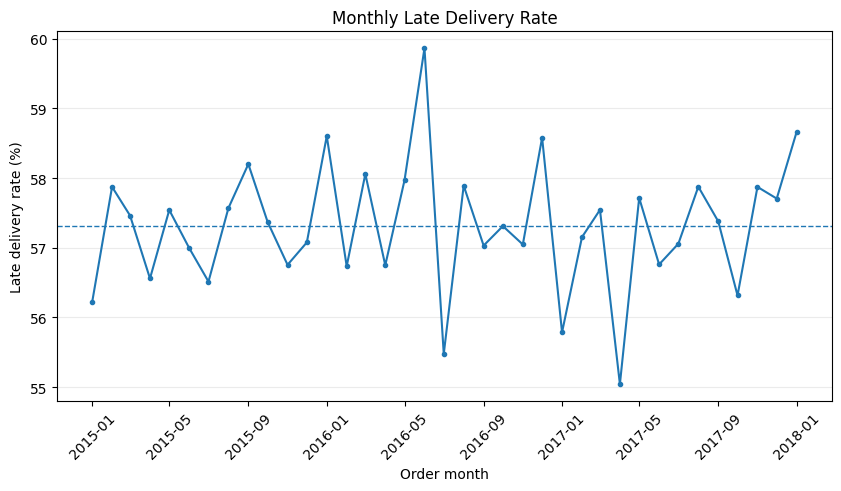

In [129]:
monthly_sla = (
    eligible_orders
    .groupby("Order_Month")
    .agg(
        Eligible_Orders=("Order Id", "nunique"),
        Late_Orders=("Is_Late", "sum")
    )
    .reset_index()
)

monthly_sla["Late_Rate"] = (
    monthly_sla["Late_Orders"]
    / monthly_sla["Eligible_Orders"]
)

monthly_sla["Order_Month_dt"] = pd.to_datetime(
    monthly_sla["Order_Month"]
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4.8))
plt.plot(
    monthly_sla["Order_Month_dt"],
    monthly_sla["Late_Rate"] * 100,
    marker="o",
    markersize=3
)
plt.axhline(
    eligible_orders["Is_Late"].mean() * 100,
    linestyle="--",
    linewidth=1
)
plt.title("Monthly Late Delivery Rate")
plt.xlabel("Order month")
plt.ylabel("Late delivery rate (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.show()

Annual and monthly late rates remain around **57%–58%**, with low monthly volatility (standard deviation of about **0.93 percentage point**). Since 2018 contains only January, it is not treated as a full-year comparison. The pattern looks persistent rather than driven by a single spike.

### 6.3 — Reliability by shipping mode

In [130]:
shipping_mode_summary = (
    eligible_orders
    .groupby("Shipping_Mode")
    .agg(
        Eligible_Orders=("Order Id", "nunique"),
        Late_Orders=("Is_Late", "sum"),
        Avg_Actual_Days=("Actual_Shipping_Days", "mean"),
        Avg_Scheduled_Days=("Scheduled_Shipping_Days", "mean"),
        Avg_Delay_Late=("Delay_Days", lambda s: s[s > 0].mean())
    )
    .reset_index()
)

shipping_mode_summary["Late_Rate"] = (
    shipping_mode_summary["Late_Orders"]
    / shipping_mode_summary["Eligible_Orders"]
)

shipping_mode_summary["Order_Share"] = (
    shipping_mode_summary["Eligible_Orders"]
    / len(eligible_orders)
)

shipping_mode_summary.sort_values(
    "Late_Rate",
    ascending=False
)

,Shipping_Mode,Eligible_Orders,Late_Orders,Avg_Actual_Days,Avg_Scheduled_Days,Avg_Delay_Late,Late_Rate,Order_Share
0,First Class,9602,9602,2.000000,1.0,1.000000,1.000000,0.152662
2,Second Class,12256,9803,4.002937,2.0,2.504131,0.799853,0.194858
1,Same Day,3407,1648,0.483710,0.0,1.000000,0.483710,0.054168
3,Standard Class,37632,14995,3.994553,4.0,1.502634,0.398464,0.598312


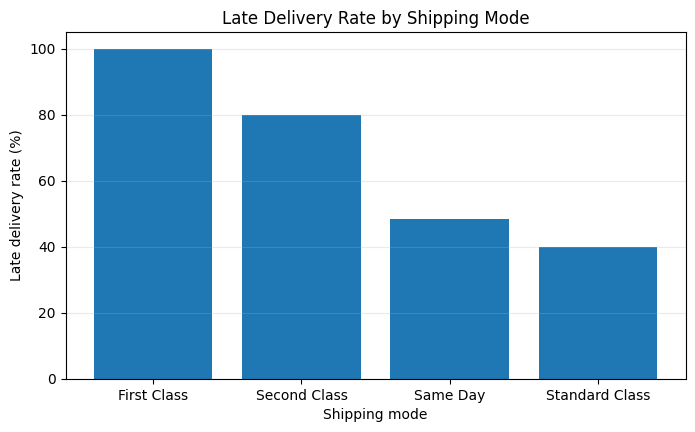

In [131]:
mode_plot = shipping_mode_summary.sort_values(
    "Late_Rate",
    ascending=False
)

plt.figure(figsize=(8, 4.5))
plt.bar(
    mode_plot["Shipping_Mode"],
    mode_plot["Late_Rate"] * 100
)
plt.title("Late Delivery Rate by Shipping Mode")
plt.xlabel("Shipping mode")
plt.ylabel("Late delivery rate (%)")
plt.ylim(0, 105)
plt.grid(axis="y", alpha=0.25)
plt.show()

Shipping-mode differences are substantial: **First Class 100% late**, **Second Class 79.99%**, **Same Day 48.37%**, and **Standard Class 39.85%**. Standard Class still carries the largest volume at about **59.83%** of eligible orders. This separates high rate risk in premium modes from high volume exposure in Standard Class.

### 6.4 — Delay severity by shipping mode

In [132]:
severity_by_mode = pd.crosstab(
    eligible_orders["Shipping_Mode"],
    eligible_orders["Delay_Severity"],
    normalize="index"
).mul(100).round(2)

severity_by_mode

Delay_Severity,1 Day Late,2 Days Late,3+ Days Late,No Delay
Shipping_Mode,,,,
First Class,100.00,0.00,0.00,0.00
Same Day,48.37,0.00,0.00,51.63
Second Class,19.76,20.18,40.05,20.01
Standard Class,19.82,20.03,0.00,60.15


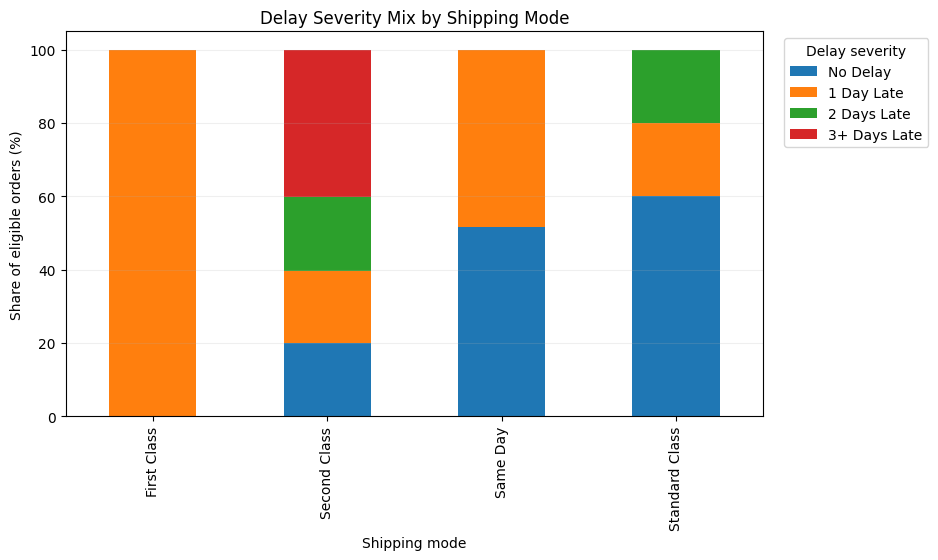

In [133]:
severity_order = [
    "No Delay",
    "1 Day Late",
    "2 Days Late",
    "3+ Days Late"
]

severity_plot = severity_by_mode[
    severity_order
].loc[
    ["First Class", "Second Class", "Same Day", "Standard Class"]
]

severity_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Delay Severity Mix by Shipping Mode")
plt.xlabel("Shipping mode")
plt.ylabel("Share of eligible orders (%)")
plt.legend(
    title="Delay severity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(axis="y", alpha=0.2)
plt.show()

Delay severity also differs by mode. First Class is always **1 day late**, while Second Class has a large share of **3+ day** delays. Standard Class has about **60.15% no delay**, and its late cases in this dataset do not exceed 2 days.

### 6.5 — Is order complexity related to late delivery?

In [134]:
complexity_sla = (
    eligible_orders
    .groupby("Order_Complexity")
    .agg(
        Eligible_Orders=("Order Id", "nunique"),
        Late_Orders=("Is_Late", "sum"),
        Avg_SLA_Gap=("SLA_Gap_Days", "mean"),
        Avg_Order_Value=("Net_Sales", "mean")
    )
    .reset_index()
)

complexity_sla["Late_Rate"] = (
    complexity_sla["Late_Orders"]
    / complexity_sla["Eligible_Orders"]
)

complexity_sla.sort_values(
    "Late_Rate",
    ascending=False
)

,Order_Complexity,Eligible_Orders,Late_Orders,Avg_SLA_Gap,Avg_Order_Value,Late_Rate
2,Single Line,18982,10928,0.571541,216.017312,0.575703
0,High Complexity,22082,12641,0.563355,805.215712,0.572457
1,Medium Complexity,21833,12479,0.563551,447.187795,0.571566


Late rates are nearly identical across order-complexity groups, ranging from about **57.16% to 57.57%**. The difference is less than half a percentage point, so order-line count does not stand out as a major differentiator.

### 6.6 — Market and customer segment

In [135]:
def late_rate_summary(column):
    summary = (
        eligible_orders
        .groupby(column)
        .agg(
            Eligible_Orders=("Order Id", "nunique"),
            Late_Orders=("Is_Late", "sum")
        )
        .reset_index()
    )

    summary["Late_Rate"] = (
        summary["Late_Orders"]
        / summary["Eligible_Orders"]
    )

    return summary.sort_values(
        "Late_Rate",
        ascending=False
    )

market_sla = late_rate_summary("Market")
segment_sla = late_rate_summary("Customer_Segment")

display(market_sla)
display(segment_sla)

,Market,Eligible_Orders,Late_Orders,Late_Rate
3,Pacific Asia,16853,9720,0.576752
4,USCA,8178,4704,0.575202
1,Europe,17763,10199,0.574171
2,LATAM,16414,9339,0.568966
0,Africa,3689,2086,0.565465


,Customer_Segment,Eligible_Orders,Late_Orders,Late_Rate
2,Home Office,11266,6505,0.577401
0,Consumer,32614,18672,0.572515
1,Corporate,19017,10871,0.571646


Late rates by market range only from about **56.55% to 57.68%**, while customer segments range from about **57.16% to 57.74%**. These differences are much smaller than the shipping-mode gap, so geography and customer mix are not the strongest signals in this dataset.

## 7 — Diagnostic analysis

### 7.1 — Quantify association strength with Cramér's V

In [136]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2, p_value, _, _ = chi2_contingency(table)

    n = table.values.sum()
    phi2 = chi2 / n
    r, k = table.shape

    # Bias-corrected Cramér's V
    phi2_corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    v = np.sqrt(
        phi2_corr
        / min(k_corr - 1, r_corr - 1)
    )

    return chi2, p_value, v


features = [
    "Shipping_Mode",
    "Market",
    "Order_Region",
    "Customer_Segment",
    "Order_Complexity",
    "Order_Year"
]

association_results = []

for feature in features:
    chi2, p_value, v = cramers_v(
        eligible_orders[feature],
        eligible_orders["Is_Late"]
    )

    association_results.append({
        "Feature": feature,
        "Chi2": chi2,
        "p_value": p_value,
        "Cramers_V": v
    })

association_df = (
    pd.DataFrame(association_results)
    .sort_values("Cramers_V", ascending=False)
)

association_df

,Feature,Chi2,p_value,Cramers_V
0,Shipping_Mode,14530.753297,0.000000,0.480604
2,Order_Region,30.666509,0.103144,0.011738
5,Order_Year,3.116022,0.374080,0.001358
1,Market,3.175294,0.528931,0.000000
3,Customer_Segment,1.061537,0.588153,0.000000
4,Order_Complexity,0.772927,0.679456,0.000000


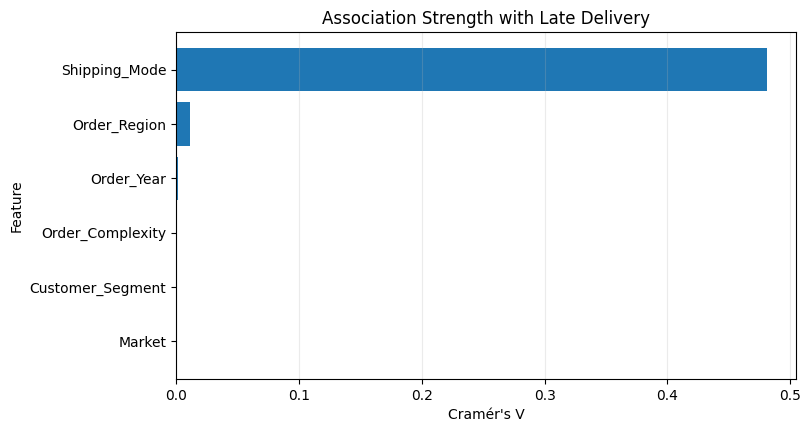

In [137]:
association_plot = association_df.sort_values(
    "Cramers_V",
    ascending=True
)

plt.figure(figsize=(8, 4.5))
plt.barh(
    association_plot["Feature"],
    association_plot["Cramers_V"]
)
plt.title("Association Strength with Late Delivery")
plt.xlabel("Cramér's V")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.25)
plt.show()

Bias-corrected **Cramér's V** identifies `Shipping_Mode` as the strongest categorical association with late delivery at **V ≈ 0.481**. Region, market, segment, complexity, and year are very small or near zero. This is evidence of association, **not proof of causation**.

### 7.2 — Deep dive: scheduled vs actual shipping days

In [138]:
actual_day_distribution = pd.crosstab(
    eligible_orders["Shipping_Mode"],
    eligible_orders["Actual_Shipping_Days"]
)

actual_day_distribution

Actual_Shipping_Days,0,1,2,3,4,5,6
Shipping_Mode,,,,,,,
First Class,0,0,9602,0,0,0,0
Same Day,1759,1648,0,0,0,0,0
Second Class,0,0,2453,2422,2473,2452,2456
Standard Class,0,0,7610,7517,7510,7458,7537


Shipping-day distributions help explain the rate differences by mode. First Class always takes **2 actual days** against a **1-day SLA**, while Second Class has a **2-day SLA** with actual values from 2 to 6 days. Standard Class has a **4-day SLA** and becomes late only at 5–6 actual days. This explains the mechanics of the SLA classification but not the operational causes of those durations.

### 7.3 — Is the shipping-mode pattern stable over time?

In [139]:
monthly_mode = (
    eligible_orders
    .groupby(["Order_Month", "Shipping_Mode"])
    .agg(
        Eligible_Orders=("Order Id", "nunique"),
        Late_Orders=("Is_Late", "sum")
    )
    .reset_index()
)

monthly_mode["Late_Rate"] = (
    monthly_mode["Late_Orders"]
    / monthly_mode["Eligible_Orders"]
)

mode_stability = (
    monthly_mode
    .groupby("Shipping_Mode")["Late_Rate"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

mode_stability

,Shipping_Mode,mean,std,min,max
0,First Class,1.000000,0.000000,1.000000,1.000000
1,Same Day,0.482674,0.082200,0.329114,0.626984
2,Second Class,0.799680,0.013567,0.768769,0.830247
3,Standard Class,0.398528,0.011244,0.379620,0.423567


The shipping-mode pattern is also stable over time. First Class remains **100% late** every month, while Second and Standard have monthly standard deviations of about **1.36 pp** and **1.12 pp**. Same Day is more variable but averages around 48%.

### 7.4 — Do late orders show worse profitability?

In [140]:
financial_by_sla = (
    eligible_orders
    .groupby("SLA_Status")
    .agg(
        Orders=("Order Id", "nunique"),
        Avg_Net_Sales=("Net_Sales", "mean"),
        Median_Net_Sales=("Net_Sales", "median"),
        Avg_Profit=("Order_Profit", "mean"),
        Median_Profit=("Order_Profit", "median"),
        Loss_Order_Rate=("Is_Loss_Order", "mean")
    )
    .reset_index()
)

financial_by_sla

,SLA_Status,Orders,Avg_Net_Sales,Median_Net_Sales,Avg_Profit,Median_Profit,Loss_Order_Rate
0,Early,15127,506.137288,457.100006,61.824901,72.439999,0.209162
1,Late,36048,501.624370,455.949997,59.366724,72.599998,0.212994
2,On Time,11722,503.819402,457.970009,62.373628,73.279998,0.209094


In [141]:
profit_gap = (
    eligible_orders.loc[
        eligible_orders["Is_Late"] == 1,
        "Order_Profit"
    ].mean()
    -
    eligible_orders.loc[
        eligible_orders["Is_Late"] == 0,
        "Order_Profit"
    ].mean()
)

sla_profit_corr = (
    eligible_orders[
        ["SLA_Gap_Days", "Order_Profit", "Net_Sales"]
    ]
    .corr()
)

print(
    f"Average profit difference (Late - Non-Late): "
    f"${profit_gap:,.2f}"
)

sla_profit_corr

Average profit difference (Late - Non-Late): $-2.70


,SLA_Gap_Days,Order_Profit,Net_Sales
SLA_Gap_Days,1.000000,-0.008646,-0.004940
Order_Profit,-0.008646,1.000000,0.200937
Net_Sales,-0.004940,0.200937,1.000000


Late orders have average profit only about **$2.70 lower** than non-late orders, `SLA_Gap_Days` has a correlation of only about **-0.009** with `Order_Profit`, and loss-order rates are nearly identical. The dataset does not support a claim that delay causes lower profit, so the financial analysis uses **exposure** rather than realized loss.

## 8 — Financial exposure and improvement scenario

### 8.1 — Financial exposure on late orders

In [142]:
late_orders = eligible_orders[
    eligible_orders["Is_Late"] == 1
].copy()

late_exposure_summary = pd.DataFrame({
    "Metric": [
        "Late Orders",
        "Late Net Sales Exposure",
        "Late Profit Exposure",
        "Avg Net Sales per Late Order",
        "Avg Profit per Late Order"
    ],
    "Value": [
        f"{len(late_orders):,}",
        f"${late_orders['Net_Sales'].sum():,.2f}",
        f"${late_orders['Order_Profit'].sum():,.2f}",
        f"${late_orders['Net_Sales'].mean():,.2f}",
        f"${late_orders['Order_Profit'].mean():,.2f}"
    ]
})

late_exposure_summary

,Metric,Value
0,Late Orders,"36,048"
1,Late Net Sales Exposure,"$18,082,555.30"
2,Late Profit Exposure,"$2,140,051.68"
3,Avg Net Sales per Late Order,$501.62
4,Avg Profit per Late Order,$59.37


In [143]:
financial_exposure_by_mode = (
    late_orders
    .groupby("Shipping_Mode")
    .agg(
        Late_Orders=("Order Id", "nunique"),
        Net_Sales_Exposure=("Net_Sales", "sum"),
        Profit_Exposure=("Order_Profit", "sum")
    )
    .reset_index()
)

financial_exposure_by_mode["Late_Order_Share"] = (
    financial_exposure_by_mode["Late_Orders"]
    / len(late_orders)
)

financial_exposure_by_mode.sort_values(
    "Profit_Exposure",
    ascending=False
)

,Shipping_Mode,Late_Orders,Net_Sales_Exposure,Profit_Exposure,Late_Order_Share
3,Standard Class,14995,7.516306e+06,874633.950685,0.415973
0,First Class,9602,4.860950e+06,616596.730658,0.266367
2,Second Class,9803,4.918063e+06,564534.480184,0.271943
1,Same Day,1648,7.872367e+05,84286.520170,0.045717


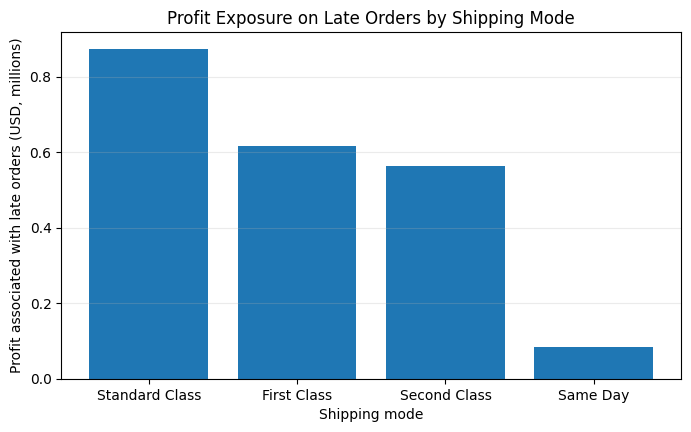

In [144]:
exposure_plot = financial_exposure_by_mode.sort_values(
    "Profit_Exposure",
    ascending=False
)

plt.figure(figsize=(8, 4.5))
plt.bar(
    exposure_plot["Shipping_Mode"],
    exposure_plot["Profit_Exposure"] / 1_000_000
)
plt.title("Profit Exposure on Late Orders by Shipping Mode")
plt.xlabel("Shipping mode")
plt.ylabel("Profit associated with late orders (USD, millions)")
plt.grid(axis="y", alpha=0.25)
plt.show()

Late orders are associated with about **$18.08M in net sales** and **$2.14M in recorded profit**. Standard Class has the largest exposure because of its volume, even though it has the lowest late rate of the four modes. These values represent transaction exposure linked to late orders, **not losses caused by delay**.

### 8.2 — Scenario: 5%, 10%, and 15% relative reduction in late orders

In [145]:
baseline_late_orders = (
    eligible_orders["Is_Late"].sum()
)

scenario_rows = []

for reduction in [0.05, 0.10, 0.15]:

    late_orders_improved = round(
        baseline_late_orders * reduction
    )

    remaining_late_orders = (
        baseline_late_orders
        - late_orders_improved
    )

    projected_late_rate = (
        remaining_late_orders
        / len(eligible_orders)
    )

    scenario_rows.append({
        "Relative_Late_Reduction": reduction,
        "Late_Orders_Improved": late_orders_improved,
        "Remaining_Late_Orders": remaining_late_orders,
        "Projected_Late_Rate": projected_late_rate
    })

scenario_df = pd.DataFrame(scenario_rows)

scenario_df

,Relative_Late_Reduction,Late_Orders_Improved,Remaining_Late_Orders,Projected_Late_Rate
0,0.05,1802,34246,0.544477
1,0.10,3605,32443,0.515812
2,0.15,5407,30641,0.487162


The scenario keeps eligible volume fixed and expresses the target as a **relative reduction** in late orders. At 10%, about **3,605 late orders** move out of the late category and the projected late rate becomes **51.58%**. This is a planning scenario, not a forecast.

## 9 — Final findings, recommendations, and limitations

### 9.1 — Key findings

1. **The data grain must be corrected before KPI calculation.** The raw dataset contains **180,519 order-item rows** but only **65,752 unique orders**. Delivery KPIs need to be calculated at order level.
2. **The SLA population is validated.** After excluding **2,855 `Shipping canceled` orders** from the SLA denominator, there are **62,897 eligible delivered orders** and **36,048 late orders (57.31%)**.
3. **The late-delivery pattern is persistent.** The late rate remains around 57%–58% across the observed period rather than being driven by a single month.
4. **Shipping Mode is the strongest observed differentiator.** First Class is **100% late**, Second Class **~80%**, Same Day **~48%**, and Standard Class **~40%**. Cramér's V for Shipping Mode is about **0.481**.
5. **Rate risk and volume risk point to different priorities.** First and Second Class have the highest late rates, while Standard Class represents **~59.8% of eligible orders** and produces **~41.6% of all late orders**.
6. **Other tested factors show little separation.** Market, customer segment, order complexity, year, and region have very small associations compared with Shipping Mode.
7. **A profitability effect is not established.** Average order profit and loss-order rates are very similar for late and non-late orders. The appropriate financial framing is therefore **financial exposure**, not realized profit loss.

### 9.2 — Recommendations

**Priority 1 — Review premium-service SLA design and execution**  
First Class and Second Class should be investigated further because their late rates are very high and persistent. The next operational analysis should examine carrier performance, dispatch queues, warehouse processing time, cut-off rules, and capacity constraints.

**Priority 2 — Use Standard Class for a volume-focused pilot**  
Standard Class has a lower late rate but the largest volume. Even a modest improvement in this mode could affect a large number of late orders.

**Priority 3 — Monitor SLA performance by shipping mode**  
The dashboard should track `Eligible Orders`, `Late Delivery Rate`, `Delay Severity`, `Actual vs Scheduled Days`, and `Late Order Count` by shipping mode and over time.

**Priority 4 — Use a measurable improvement target**  
A **10% relative reduction in late orders** corresponds to roughly **3,605 orders** moving out of the late category and a projected late rate of **51.58%**, assuming the eligible-order denominator remains fixed.

**Priority 5 — Collect operational data before claiming a root cause**  
Useful additions include carrier, warehouse/fulfillment center, staffing and capacity, dispatch timestamp, promised delivery timestamp, route distance, refunds/returns, complaints, and retention/churn.

### 9.3 — Limitations

- The dataset does not include carrier, warehouse capacity, staffing, pick/pack process, dispatch queue, or route-level operating fields.
- `Days for shipping (real)` is based on **calendar-date difference**, not precise elapsed hours; this definition was validated against the order and shipping dates.
- `Profit Exposure` is recorded profit attached to late orders, **not profit lost because of delay**.
- Order dates run from January 2015 through January 2018; 2018 is only a partial year.
- Shipping-mode patterns are strong in the dataset but should not be interpreted as operational causation without additional evidence.

### 9.4 — Final metric definitions

| Metric | Definition |
|---|---|
| Total Orders | Unique `Order Id` count |
| Eligible Delivered Orders | Orders where `Delivery_Status != "Shipping canceled"` |
| SLA Gap Days | `Actual_Shipping_Days - Scheduled_Shipping_Days` |
| Late Order | Eligible order where `SLA_Gap_Days > 0` |
| On-Time Order | Eligible order where `SLA_Gap_Days = 0` |
| Early Order | Eligible order where `SLA_Gap_Days < 0` |
| Late Delivery Rate | `Late Orders / Eligible Delivered Orders` |
| Cancellation Rate | `Shipping Canceled Orders / Total Orders` |
| Delay Days | `max(SLA_Gap_Days, 0)` |
| Financial Exposure | Sales/profit associated with late orders; **not realized loss** |

## 10 — Export Tableau-ready data and analysis outputs

In [146]:
tableau_columns = [
    "Order Id",
    "Order_Date",
    "Shipping_Date",
    "Order_Year",
    "Order_Month",
    "Order_Quarter",
    "Shipping_Mode",
    "Delivery_Status",
    "Order_Status",
    "Actual_Shipping_Days",
    "Scheduled_Shipping_Days",
    "SLA_Gap_Days",
    "SLA_Status",
    "Delay_Severity",
    "Delay_Days",
    "Market",
    "Order_Region",
    "Order_Country",
    "Customer_Segment",
    "Order_Line_Count",
    "Order_Complexity",
    "Total_Quantity",
    "Gross_Sales",
    "Total_Discount",
    "Net_Sales",
    "Order_Profit",
    "Is_Eligible",
    "Is_Late",
    "Is_On_Time",
    "Is_Early",
    "Is_Canceled",
    "Is_Loss_Order"
]

tableau_df = orders_df[
    tableau_columns
].copy()

PROCESSED_PATH = (
    PROJECT_PATH
    / "data"
    / "processed"
    / "delivery_orders_tableau_ready.csv"
)

tableau_df.to_csv(
    PROCESSED_PATH,
    index=False
)

monthly_sla.to_csv(
    PROJECT_PATH / "outputs" / "monthly_sla_trend.csv",
    index=False
)

shipping_mode_summary.to_csv(
    PROJECT_PATH / "outputs" / "shipping_mode_summary.csv",
    index=False
)

financial_exposure_by_mode.to_csv(
    PROJECT_PATH / "outputs" / "financial_exposure_by_mode.csv",
    index=False
)

association_df.to_csv(
    PROJECT_PATH / "outputs" / "association_strength.csv",
    index=False
)

scenario_df.to_csv(
    PROJECT_PATH / "outputs" / "improvement_scenarios.csv",
    index=False
)

print(f"Tableau-ready dataset: {PROCESSED_PATH}")
print(f"Rows: {len(tableau_df):,}")
print(f"Columns: {tableau_df.shape[1]:,}")

Tableau-ready dataset: /content/drive/MyDrive/DEPP Delivery Project/data/processed/delivery_orders_tableau_ready.csv
Rows: 65,752
Columns: 32


The final Tableau dataset contains **65,752 rows × 32 columns** at **one row per order**. The dashboard should use this order-level source so multi-item orders do not receive extra weight.

## Notebook complete ✅

Analysis pipeline:

**Raw data → Grain validation → Order-level model → KPI validation → Data quality audit → Feature engineering → EDA → Diagnostic analysis → Financial exposure → Improvement scenario → Tableau export**

### Tableau dashboard handoff
Primary source:
`DEPP Delivery Project/data/processed/delivery_orders_tableau_ready.csv`

The notebook prepares data for:
1. **Executive reliability** — Total Orders, Eligible Orders, Late Rate, Cancellation Rate, and average delay.
2. **Shipping-mode reliability** — volume, late rate, severity, and scheduled vs actual days.
3. **Diagnostic drilldown** — market, region, segment, complexity, and monthly trend.
4. **Financial exposure** — late-order sales/profit exposure plus a clearly labeled improvement scenario.